In [1]:
from google.colab import files
uploaded = files.upload()


Saving api_data_aadhar_enrolment.zip to api_data_aadhar_enrolment.zip


In [2]:
!unzip api_data_aadhar_enrolment.zip

Archive:  api_data_aadhar_enrolment.zip
   creating: api_data_aadhar_enrolment/
  inflating: api_data_aadhar_enrolment/api_data_aadhar_enrolment_0_500000.csv  
  inflating: api_data_aadhar_enrolment/api_data_aadhar_enrolment_1000000_1006029.csv  
  inflating: api_data_aadhar_enrolment/api_data_aadhar_enrolment_500000_1000000.csv  


In [3]:
import pandas as pd
import glob
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from statsmodels.tsa.seasonal import seasonal_decompose


In [4]:
path = "api_data_aadhar_enrolment/*.csv"
csv_files = glob.glob(path)

enrolment_df = pd.concat(
    (pd.read_csv(file) for file in csv_files),
    ignore_index=True
)

print("Combined Dataset Shape:", enrolment_df.shape)
enrolment_df.head()

Combined Dataset Shape: (1006029, 7)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,31-12-2025,Karnataka,Bidar,585330,2,3,0
1,31-12-2025,Karnataka,Bidar,585402,6,0,0
2,31-12-2025,Karnataka,Bidar,585413,1,0,0
3,31-12-2025,Karnataka,Bidar,585418,1,2,0
4,31-12-2025,Karnataka,Bidar,585421,4,3,0


In [5]:
print(enrolment_df.columns,'\n')
print(enrolment_df.info(),'\n')
print(enrolment_df.isnull().sum(),'\n')
print(enrolment_df.duplicated().sum(),'\n')


Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5         1006029 non-null  int64 
 5   age_5_17        1006029 non-null  int64 
 6   age_18_greater  1006029 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 53.7+ MB
None 

date              0
state             0
district          0
pincode           0
age_0_5           0
age_5_17          0
age_18_greater    0
dtype: int64 

22957 



In [6]:
before = enrolment_df.shape[0]
enrolment_df.drop_duplicates(inplace=True)
after = enrolment_df.shape[0]

print(f"Removed {before - after} duplicate rows")


Removed 22957 duplicate rows


In [7]:
print(enrolment_df['state'].nunique())
enrolment_df['state'].unique()

55


array(['Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh',
       'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
       'Odisha', 'Orissa', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Andhra Pradesh',
       'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh',
       'Chhattisgarh', 'Daman and Diu', 'Delhi', 'Goa', 'Gujarat',
       'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand',
       'Pondicherry', 'The Dadra And Nagar Haveli And Daman And Diu',
       'Jammu And Kashmir', 'Dadra and Nagar Haveli and Daman and Diu',
       'Andaman and Nicobar Islands', 'Andaman & Nicobar Islands',
       'Dadra & Nagar Haveli', 'Dadra and Nagar Haveli', 'WEST BENGAL',
       'Jammu & Kashmir', 'West  Bengal', '100000', 'Daman & Diu',
       'West Bangal', 'Westbengal', 'West bengal', 'andhra pradesh',
       'ODISHA', 'WESTBENGAL'], dtype=object)

In [8]:
# Basic normalization
enrolment_df['state'] = (
    enrolment_df['state']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('&', 'and')
    .str.replace('  ', ' ')
)
enrolment_df['state'].unique()

state_mapping = {
    # West Bengal
    'west bengal': 'West Bengal',
    'west bangal': 'West Bengal',
    'westbengal': 'West Bengal',
    'west  bengal': 'West Bengal',
    'westbengal ': 'West Bengal',
    'west bengli':  'West Bengal',


    # Andhra Pradesh
    'andhra pradesh': 'Andhra Pradesh',

    # Odisha
    'odisha': 'Odisha',
    'orissa': 'Odisha',

    # Jammu & Kashmir
    'jammu and kashmir': 'Jammu and Kashmir',
    'jammu kashmir': 'Jammu and Kashmir',

    # Collapse all Dadra / Daman variants into ONE state
    'dadra nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra and nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra and nagar haveli and daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'the dadra and nagar haveli and daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman diu': 'Dadra and Nagar Haveli and Daman and Diu',


    # Puducherry
    'puducherry': 'Puducherry',


    # Andaman & Nicobar Islands
    'andaman and nicobar islands': 'Andaman and Nicobar Islands',
    'andaman nicobar islands': 'Andaman and Nicobar Islands',

    # Puducherry
    'pondicherry': 'Puducherry',

    # Case-normalized direct matches
    'delhi': 'Delhi',
    'ladakh': 'Ladakh',
    'goa': 'Goa',
    'sikkim': 'Sikkim',
    'assam': 'Assam',
    'bihar': 'Bihar',
    'punjab': 'Punjab',
    'kerala': 'Kerala',
    'haryana': 'Haryana',
    'gujarat': 'Gujarat',
    'tamil nadu': 'Tamil Nadu',
    'telangana': 'Telangana',
    'karnataka': 'Karnataka',
    'maharashtra': 'Maharashtra',
    'Nagpur': 'Maharashtra',
    'rajasthan': 'Rajasthan',
    'uttar pradesh': 'Uttar Pradesh',
    'madhya pradesh': 'Madhya Pradesh',
    'himachal pradesh': 'Himachal Pradesh',
    'arunachal pradesh': 'Arunachal Pradesh',
    'chhattisgarh': 'Chhattisgarh',
    'chhatisgarh' : 'Chhattisgarh',
    'jharkhand': 'Jharkhand',
    'manipur': 'Manipur',
    'meghalaya': 'Meghalaya',
    'mizoram': 'Mizoram',
    'nagaland': 'Nagaland',
    'tripura': 'Tripura',
    'uttarakhand': 'Uttarakhand',
    'lakshadweep': 'Lakshadweep',
    'chandigarh': 'Chandigarh'
}
enrolment_df['state'] = enrolment_df['state'].replace(state_mapping)
# Remove numeric / invalid state entries
enrolment_df = enrolment_df[~enrolment_df['state'].str.isnumeric()]
print(enrolment_df['state'].nunique())
enrolment_df['state'].unique()


36


array(['Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh',
       'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
       'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Andhra Pradesh',
       'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh',
       'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu and Kashmir', 'Jharkhand', 'Andaman and Nicobar Islands'],
      dtype=object)

In [9]:
enrolment_df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,31-12-2025,Karnataka,Bidar,585330,2,3,0
1,31-12-2025,Karnataka,Bidar,585402,6,0,0
2,31-12-2025,Karnataka,Bidar,585413,1,0,0
3,31-12-2025,Karnataka,Bidar,585418,1,2,0
4,31-12-2025,Karnataka,Bidar,585421,4,3,0


In [10]:
df_up=enrolment_df[enrolment_df['state']=='Uttar Pradesh']
print(df_up['district'].nunique())
df_up['district'].unique()

89


array(['Agra', 'Aligarh', 'Allahabad', 'Ambedkar Nagar', 'Amethi',
       'Amroha', 'Ayodhya', 'Azamgarh', 'Baghpat', 'Bahraich', 'Ballia',
       'Balrampur', 'Banda', 'Bara Banki', 'Barabanki', 'Bareilly',
       'Basti', 'Bhadohi', 'Bijnor', 'Budaun', 'Bulandshahr', 'Chandauli',
       'Deoria', 'Etah', 'Etawah', 'Faizabad', 'Farrukhabad', 'Fatehpur',
       'Firozabad', 'Gautam Buddha Nagar', 'Ghaziabad', 'Ghazipur',
       'Gonda', 'Gorakhpur', 'Hamirpur', 'Hapur', 'Hardoi', 'Hathras',
       'Jalaun', 'Jaunpur', 'Jhansi', 'Jyotiba Phule Nagar', 'Kannauj',
       'Kanpur Dehat', 'Kanpur Nagar', 'Kasganj', 'Kaushambi', 'Kheri',
       'Kushinagar', 'Lalitpur', 'Lucknow', 'Maharajganj', 'Mahoba',
       'Mainpuri', 'Mathura', 'Mau', 'Meerut', 'Mirzapur', 'Moradabad',
       'Muzaffarnagar', 'Pratapgarh', 'Prayagraj', 'Rae Bareli', 'Rampur',
       'Saharanpur', 'Sambhal', 'Sant Kabir Nagar', 'Sant Ravidas Nagar',
       'Shahjahanpur', 'Shamli', 'Shrawasti', 'Siddharthnagar', 'Sitap

In [11]:
import re
import pandas as pd

# Clean the district name
def clean_name(x):
    if pd.isna(x):
        return x
    x = str(x).lower()  # Convert to lowercase
    x = re.sub(r'[^a-z\s]', ' ', x)  # Remove special characters, numbers, etc.
    x = re.sub(r'\s+', ' ', x).strip()  # Replace multiple spaces with a single space
    return x

# Fix known unmatched cases
def fix_special_cases(x):
    if pd.isna(x):
        return x
    x = str(x).lower()

    # Fix known unmatched cases
    if 'kushinagar' in x and '*' in x:
        x = x.replace('*', '').strip()  # Remove the '*' from "kushinagar *"
    if 'sant ravidas nagar bhadohi' in x:
        x = 'sant ravidas nagar'  # Normalize the combined name
    if 'shravasti' in x:
        x = 'shrawasti'  # Correct the spelling variation

    return x

# Example district mapping (already provided)
districts_mapping = {
    'agra': 'Agra',
    'aligarh': 'Aligarh',
    'allahabad': 'Allahabad',
    'ambedkar nagar': 'Ambedkar Nagar',
    'amethi': 'Amethi',
    'amroha': 'Amroha',
    'ayodhya': 'Ayodhya',
    'azamgarh': 'Azamgarh',
    'baghpat': 'Baghpat',
    'bahraich': 'Bahraich',
    'ballia': 'Ballia',
    'balrampur': 'Balrampur',
    'banda': 'Banda',
    'bara banki': 'Bara Banki',
    'barabanki': 'Barabanki',
    'bareilly': 'Bareilly',
    'basti': 'Basti',
    'bhadohi': 'Bhadohi',
    'bijnor': 'Bijnor',
    'budaun': 'Budaun',
    'bulandshahr': 'Bulandshahr',
    'chandauli': 'Chandauli',
    'deoria': 'Deoria',
    'etah': 'Etah',
    'etawah': 'Etawah',
    'faizabad': 'Faizabad',
    'farrukhabad': 'Farrukhabad',
    'fatehpur': 'Fatehpur',
    'firozabad': 'Firozabad',
    'gautam buddha nagar': 'Gautam Buddha Nagar',
    'ghaziabad': 'Ghaziabad',
    'ghazipur': 'Ghazipur',
    'gonda': 'Gonda',
    'gorakhpur': 'Gorakhpur',
    'hamirpur': 'Hamirpur',
    'hapur': 'Hapur',
    'hardoi': 'Hardoi',
    'hathras': 'Hathras',
    'jalaun': 'Jalaun',
    'jaunpur': 'Jaunpur',
    'jhansi': 'Jhansi',
    'jyotiba phule nagar': 'Jyotiba Phule Nagar',
    'kannauj': 'Kannauj',
    'kanpur dehat': 'Kanpur Dehat',
    'kanpur nagar': 'Kanpur Nagar',
    'kasganj': 'Kasganj',
    'kaushambi': 'Kaushambi',
    'kheri': 'Kheri',
    'kushinagar': 'Kushinagar',
    'lalitpur': 'Lalitpur',
    'lucknow': 'Lucknow',
    'maharajganj': 'Maharajganj',
    'mahoba': 'Mahoba',
    'mainpuri': 'Mainpuri',
    'mathura': 'Mathura',
    'mau': 'Mau',
    'meerut': 'Meerut',
    'mirzapur': 'Mirzapur',
    'moradabad': 'Moradabad',
    'muzaffarnagar': 'Muzaffarnagar',
    'pratapgarh': 'Pratapgarh',
    'prayagraj': 'Prayagraj',
    'rae bareli': 'Rae Bareli',
    'rampur': 'Rampur',
    'saharanpur': 'Saharanpur',
    'sambhal': 'Sambhal',
    'sant kabir nagar': 'Sant Kabir Nagar',
    'sant ravidas nagar': 'Sant Ravidas Nagar',
    'shahjahanpur': 'Shahjahanpur',
    'shamli': 'Shamli',
    'shrawasti': 'Shrawasti',
    'siddharthnagar': 'Siddharthnagar',
    'sitapur': 'Sitapur',
    'sonbhadra': 'Sonbhadra',
    'sultanpur': 'Sultanpur',
    'unnao': 'Unnao',
    'varanasi': 'Varanasi',
    'auraiya': 'Auraiya',
    'chitrakoot': 'Chitrakoot',
    'pilibhit': 'Pilibhit',
    'shrasti': 'Shravasti',
    'siddharth nagar': 'Siddharth Nagar',
    'kushi nagar': 'Kushi Nagar',
    'bulandshahar': 'Bulandshahar',
    'raebareli': 'Raebareli',
    'mahrajganj': 'Mahrajganj',
    'bagpat': 'Bagpat'
}

# Apply cleaning and fixing directly to the district column
df_up['district'] = (
    df_up['district']
    .apply(clean_name)  # Apply cleaning function
    .apply(fix_special_cases)  # Apply special fixes (like for 'kushinagar *', etc.)
)

# Map to standard names and fill unmatched with the original district name
df_up['district'] = df_up['district'].map(districts_mapping).fillna(df_up['district'])

# Find unmatched district names (districts not in the mapping)
unmatched_districts = df_up[~df_up['district'].isin(districts_mapping.values())]['district'].unique()

# Display unmatched district names
print("Unmatched districts:", unmatched_districts)

# Inspect the result
print("Number of unique districts:", df_up['district'].nunique())
print("Unique districts:", df_up['district'].unique())


Unmatched districts: []
Number of unique districts: 86
Unique districts: ['Agra' 'Aligarh' 'Allahabad' 'Ambedkar Nagar' 'Amethi' 'Amroha' 'Ayodhya'
 'Azamgarh' 'Baghpat' 'Bahraich' 'Ballia' 'Balrampur' 'Banda' 'Bara Banki'
 'Barabanki' 'Bareilly' 'Basti' 'Bhadohi' 'Bijnor' 'Budaun' 'Bulandshahr'
 'Chandauli' 'Deoria' 'Etah' 'Etawah' 'Faizabad' 'Farrukhabad' 'Fatehpur'
 'Firozabad' 'Gautam Buddha Nagar' 'Ghaziabad' 'Ghazipur' 'Gonda'
 'Gorakhpur' 'Hamirpur' 'Hapur' 'Hardoi' 'Hathras' 'Jalaun' 'Jaunpur'
 'Jhansi' 'Jyotiba Phule Nagar' 'Kannauj' 'Kanpur Dehat' 'Kanpur Nagar'
 'Kasganj' 'Kaushambi' 'Kheri' 'Kushinagar' 'Lalitpur' 'Lucknow'
 'Maharajganj' 'Mahoba' 'Mainpuri' 'Mathura' 'Mau' 'Meerut' 'Mirzapur'
 'Moradabad' 'Muzaffarnagar' 'Pratapgarh' 'Prayagraj' 'Rae Bareli'
 'Rampur' 'Saharanpur' 'Sambhal' 'Sant Kabir Nagar' 'Sant Ravidas Nagar'
 'Shahjahanpur' 'Shamli' 'Shrawasti' 'Siddharthnagar' 'Sitapur'
 'Sonbhadra' 'Sultanpur' 'Unnao' 'Varanasi' 'Auraiya' 'Chitrakoot'
 'Pilibhit' 'S

/tmp/ipython-input-2645018904.py:121: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_up['district'] = (
/tmp/ipython-input-2645018904.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_up['district'] = df_up['district'].map(districts_mapping).fillna(df_up['district'])


In [12]:
# Find unmatched district names (districts not in the mapping)
unmatched_districts = df_up[~df_up['district'].isin(districts_mapping.keys())]['district'].unique()

# Display unmatched district names
print(unmatched_districts)


['Agra' 'Aligarh' 'Allahabad' 'Ambedkar Nagar' 'Amethi' 'Amroha' 'Ayodhya'
 'Azamgarh' 'Baghpat' 'Bahraich' 'Ballia' 'Balrampur' 'Banda' 'Bara Banki'
 'Barabanki' 'Bareilly' 'Basti' 'Bhadohi' 'Bijnor' 'Budaun' 'Bulandshahr'
 'Chandauli' 'Deoria' 'Etah' 'Etawah' 'Faizabad' 'Farrukhabad' 'Fatehpur'
 'Firozabad' 'Gautam Buddha Nagar' 'Ghaziabad' 'Ghazipur' 'Gonda'
 'Gorakhpur' 'Hamirpur' 'Hapur' 'Hardoi' 'Hathras' 'Jalaun' 'Jaunpur'
 'Jhansi' 'Jyotiba Phule Nagar' 'Kannauj' 'Kanpur Dehat' 'Kanpur Nagar'
 'Kasganj' 'Kaushambi' 'Kheri' 'Kushinagar' 'Lalitpur' 'Lucknow'
 'Maharajganj' 'Mahoba' 'Mainpuri' 'Mathura' 'Mau' 'Meerut' 'Mirzapur'
 'Moradabad' 'Muzaffarnagar' 'Pratapgarh' 'Prayagraj' 'Rae Bareli'
 'Rampur' 'Saharanpur' 'Sambhal' 'Sant Kabir Nagar' 'Sant Ravidas Nagar'
 'Shahjahanpur' 'Shamli' 'Shrawasti' 'Siddharthnagar' 'Sitapur'
 'Sonbhadra' 'Sultanpur' 'Unnao' 'Varanasi' 'Auraiya' 'Chitrakoot'
 'Pilibhit' 'Siddharth Nagar' 'Kushi Nagar' 'Bulandshahar' 'Raebareli'
 'Mahrajganj' 'B

In [13]:
df_up['district'].nunique()

86

In [14]:

df_up[df_up['district']=='kushinagar *']

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater


In [15]:
# Convert date column to datetime
enrolment_df['date'] = pd.to_datetime(
    enrolment_df['date'],
    format='%d-%m-%Y',
    errors='coerce'
)

# Extract time features
enrolment_df['year'] = enrolment_df['date'].dt.year
enrolment_df['month'] = enrolment_df['date'].dt.month
enrolment_df['month_name'] = enrolment_df['date'].dt.month_name()

enrolment_df[['date', 'year', 'month']].head()


,date,year,month
0,2025-12-31,2025,12
1,2025-12-31,2025,12
2,2025-12-31,2025,12
3,2025-12-31,2025,12
4,2025-12-31,2025,12


In [16]:
enrolment_df['total_enrolments'] = (
    enrolment_df['age_0_5'] +
    enrolment_df['age_5_17'] +
    enrolment_df['age_18_greater']
)

enrolment_df[['age_0_5', 'age_5_17', 'age_18_greater', 'total_enrolments']].head()


,age_0_5,age_5_17,age_18_greater,total_enrolments
0,2,3,0,5
1,6,0,0,6
2,1,0,0,1
3,1,2,0,3
4,4,3,0,7


# Age-Wise Enrolment Analysis

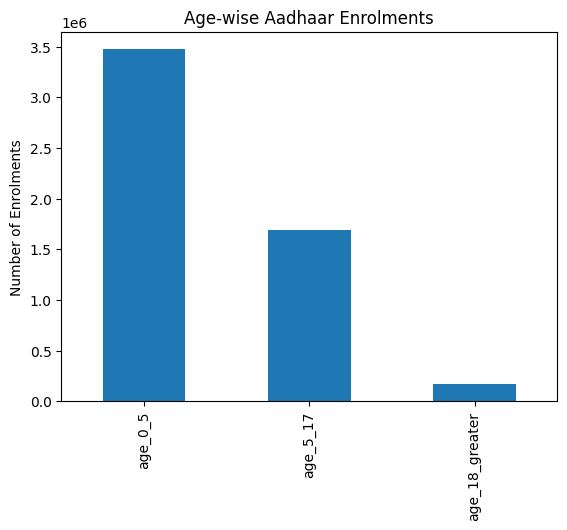

In [17]:
age_totals = enrolment_df[['age_0_5', 'age_5_17', 'age_18_greater']].sum()

age_totals.plot(kind='bar', title='Age-wise Aadhaar Enrolments')
plt.ylabel("Number of Enrolments")
plt.show()


0–5 → early inclusion has most enrollment

5–17 → school-linked enrolments had medium enrollment

18+ → workforce & adult onboarding has lowest

# Statewise Enrollment Trend

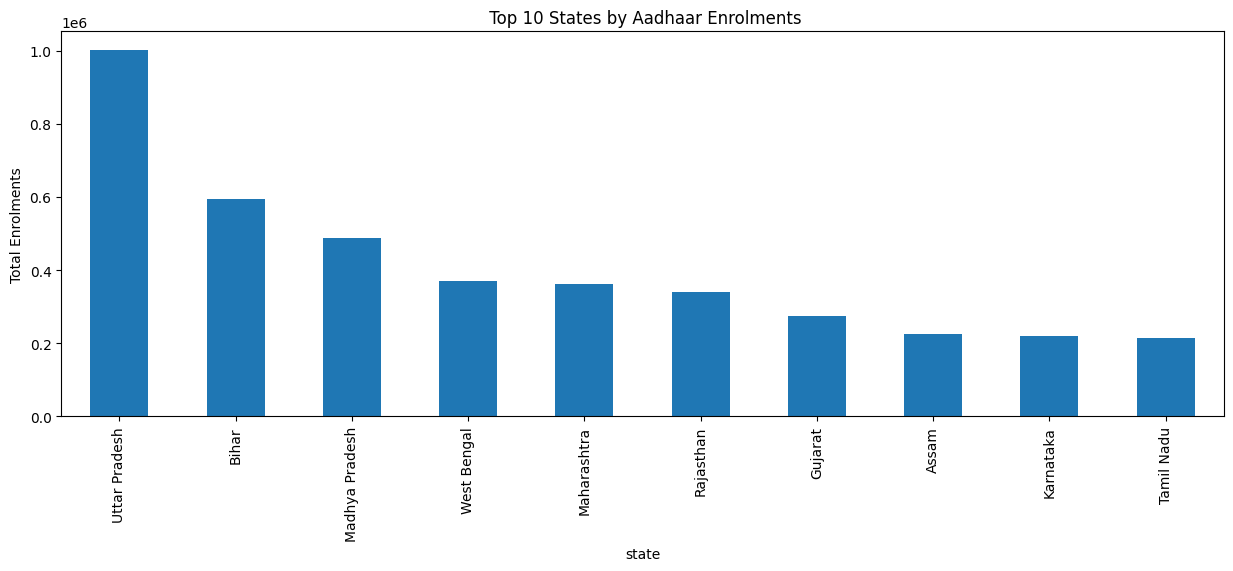

In [18]:
state_enrol = enrolment_df.groupby('state')['total_enrolments'].sum().sort_values(ascending=False)

plt.figure(figsize=(15,5))
state_enrol.head(10).plot(kind='bar')
plt.title(" Top 10 States by Aadhaar Enrolments")
plt.ylabel("Total Enrolments")
plt.show()


Total enrolments are highest in UP

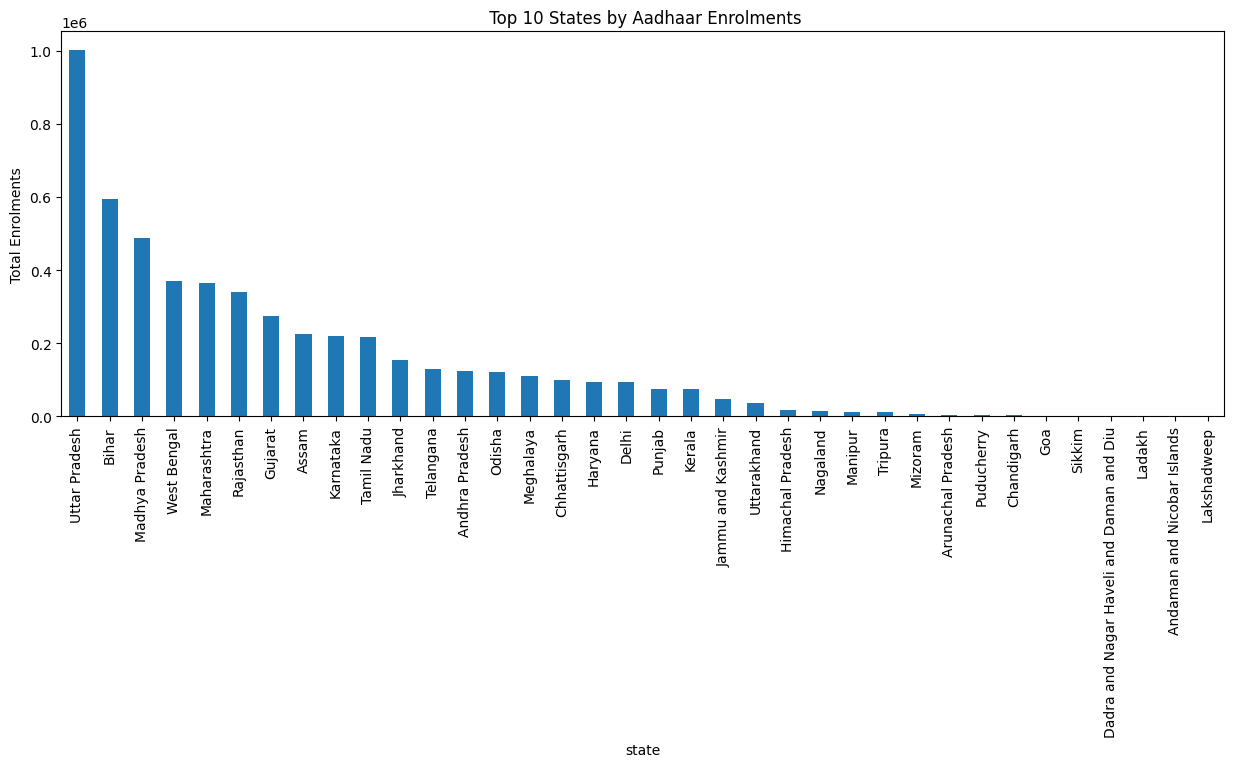

In [19]:
state_enrol = enrolment_df.groupby('state')['total_enrolments'].sum().sort_values(ascending=False)

plt.figure(figsize=(15,5))
state_enrol.head(36).plot(kind='bar')
plt.title(" Top 10 States by Aadhaar Enrolments")
plt.ylabel("Total Enrolments")
plt.show()


**Problem 1: “Invisible States” Risk**

Issue:Low Aadhaar enrolment → citizens excluded from:DBT,Ration,Pension
,Disaster relief

States at risk:
Ladakh,
Lakshadweep,
DNH & DD,Andaman & Nicobar

Govt Action:

* Mobile enrolment vans

* Special tribal/remote drives

* Disaster-ready enrolment planning

**Problem 2: “Saturation vs Growth Mismatch”**

Issue:
Some big states:Uttar Pradesh, Bihar, Madhya Pradesh, West Bengal dominate enrolments but slowing growth

Means saturation OR administrative friction

UIDAI needs to shift resources dynamically





# Time-Series Trend Analysis

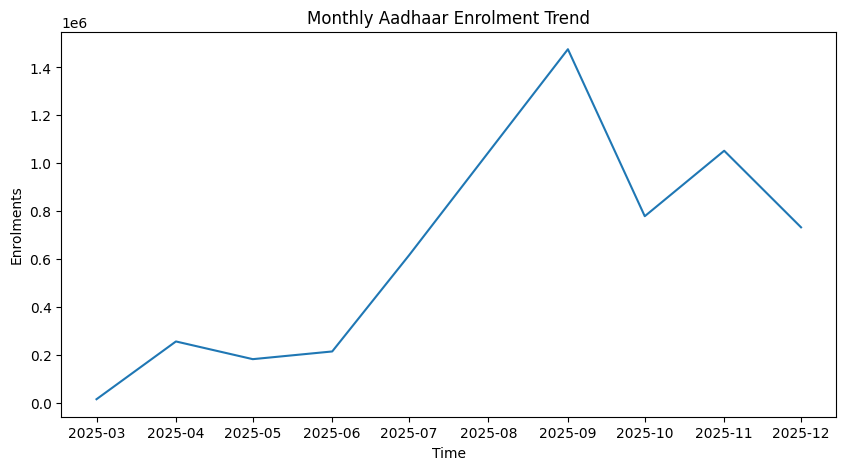

In [20]:
monthly_trend = enrolment_df.groupby(
    ['year', 'month']
)['total_enrolments'].sum().reset_index()

monthly_trend['date'] = pd.to_datetime(
    monthly_trend['year'].astype(str) + '-' + monthly_trend['month'].astype(str)
)

plt.figure(figsize=(10,5))
plt.plot(monthly_trend['date'], monthly_trend['total_enrolments'])
plt.title("Monthly Aadhaar Enrolment Trend")
plt.xlabel("Time")
plt.ylabel("Enrolments")
plt.show()



Sharp rise from July to September and Peak around September then Drop after October

Real-World Explanation:

* School admissions

* Anganwadi / early-childhood documentation

* Government campaigns often cluster mid-year

Government Action Enabled:

i) Plan child Aadhaar drives before July

ii) Pre-position enrolment kits & operators

This directly helps operational planning

# Avg Growth rate by state

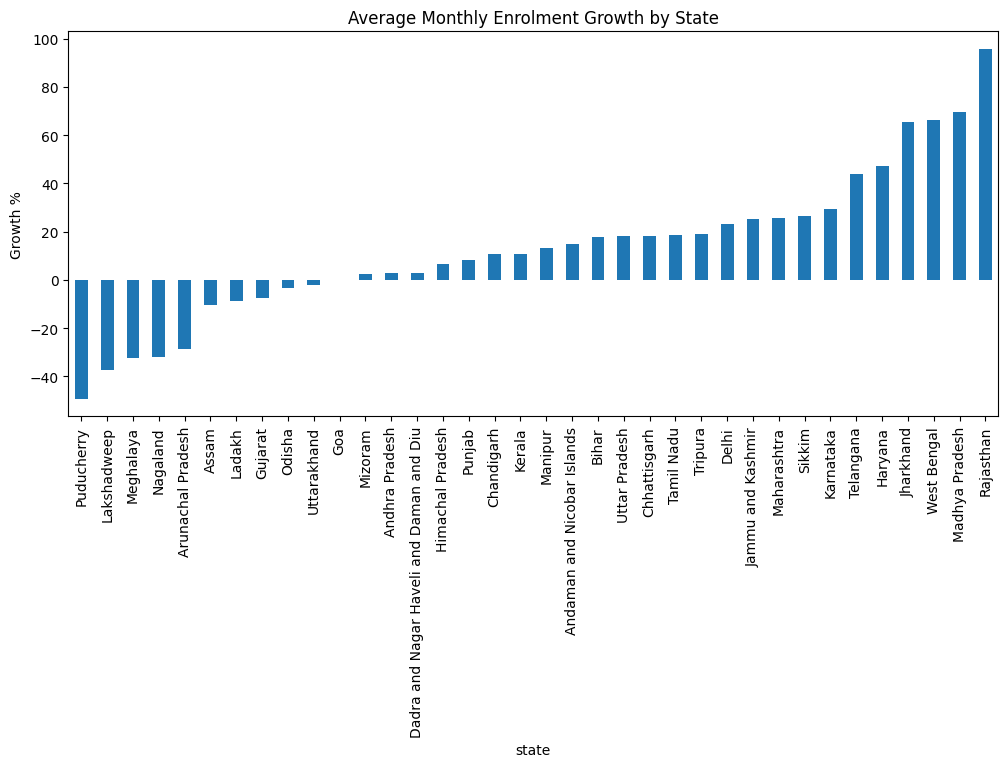

In [21]:
state_month = (
    enrolment_df
    .groupby(['state', 'month'])['total_enrolments']
    .sum()
    .reset_index()
)

state_month['growth_pct'] = (
    state_month
    .groupby('state')['total_enrolments']
    .pct_change() * 100
)

growth_state = (
    state_month
    .groupby('state')['growth_pct']
    .median()
    .sort_values()
)

plt.figure(figsize=(12,5))
growth_state.plot(kind='bar')
plt.title("Average Monthly Enrolment Growth by State")
plt.ylabel("Growth %")
plt.show()


Instead of absolute enrolments, we analysed volatility in enrolment growth. States with extreme growth values often indicate irregular enrolment cycles, suggesting operational bottlenecks, seasonal drives, or verification backlogs.”

Now suddenly:

Rajasthan ≠ “best performing”

Rajasthan = high volatility risk

# Monthly Enrolments Pattern

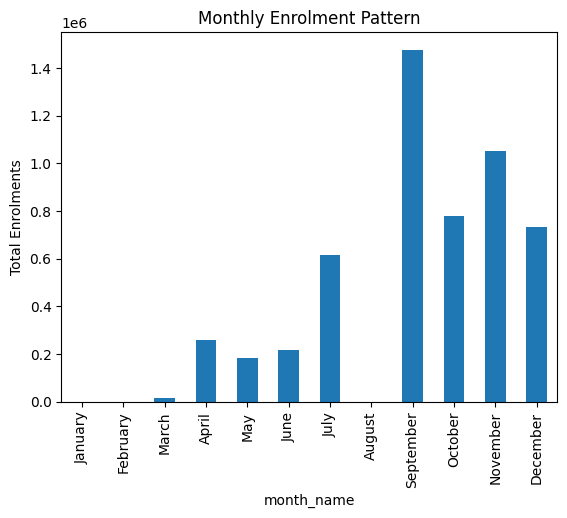

In [22]:
month_pattern = enrolment_df.groupby('month_name')['total_enrolments'].sum()

month_pattern = month_pattern.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

month_pattern.plot(kind='bar', title='Monthly Enrolment Pattern')
plt.ylabel("Total Enrolments")
plt.show()


September Month has highest enrollments whereas month like jan,feb aug has no enrollments at all

# Build Adult Enrolment Volatility Index (AEVI)
 Definition:AEVI = Standard deviation of monthly adult enrolment growth

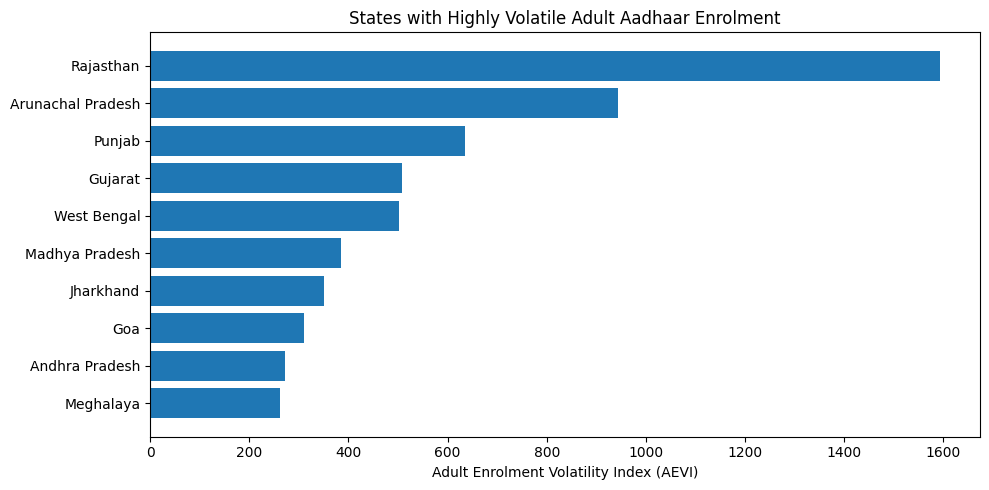

In [45]:


# Convert date
enrolment_df['date'] = pd.to_datetime(enrolment_df['date'])

# Create month column
enrolment_df['month'] = enrolment_df['date'].dt.to_period('M')
#Aggregate adult (18+) enrolments monthly by state

adult_monthly = (
    enrolment_df
    .groupby(['state', 'month'])['age_18_greater']
    .sum()
    .reset_index()
)
#Calculate month-to-month growth in adult enrolments

adult_monthly['adult_growth_pct'] = (
    adult_monthly
    .groupby('state')['age_18_greater']
    .pct_change() * 100
)



aevi = (
    adult_monthly
    .groupby('state')['adult_growth_pct']
    .std()
    .dropna()
    .sort_values(ascending=False)
)
#High AEVI = unstable / irregular adult enrolment

#Visualise TOP risk states (THIS IS YOUR MAIN GRAPH)

top_aevi = aevi.head(10)

plt.figure(figsize=(10,5))
plt.barh(top_aevi.index, top_aevi.values)
plt.xlabel("Adult Enrolment Volatility Index (AEVI)")
plt.title("States with Highly Volatile Adult Aadhaar Enrolment")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()









• Certain states like Rajasthan ,Andhra pradesh exhibit high volatility in adult Aadhaar enrolment, despite moderate overall enrolment volumes.


• Such volatility suggests irregular enrolment cycles, which may increase verification load and operational risk.

• Stable states show consistent adult enrolment behaviour, indicating mature enrolment ecosystems.

#Share of Adult Enrolments by Top States

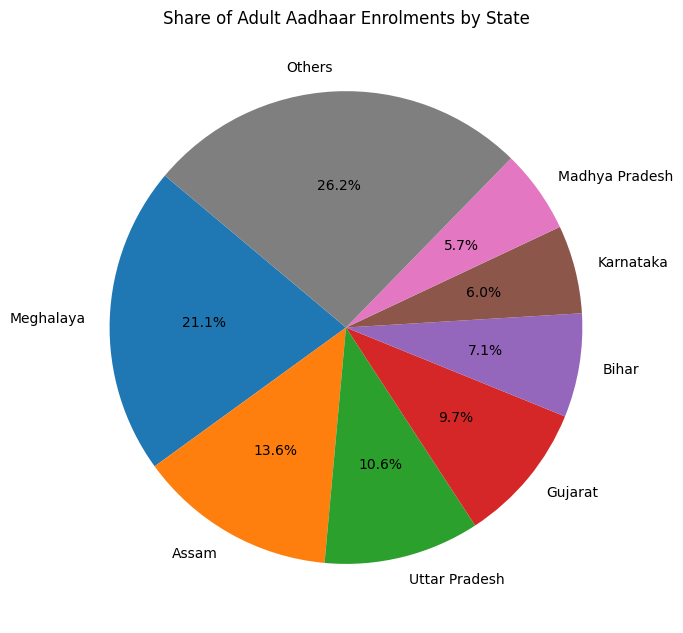

In [24]:
# Total adult enrolments by state
adult_total = (
    enrolment_df
    .groupby('state')['age_18_greater']
    .sum()
    .sort_values(ascending=False)
)

# Take top 7 states, rest as 'Others'
top_states = adult_total.head(7)
others = adult_total[7:].sum()

pie_data = pd.concat([top_states, pd.Series({'Others': others})])

plt.figure(figsize=(7,7))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140)
plt.title("Share of Adult Aadhaar Enrolments by State")
plt.tight_layout()
plt.show()


• Adult Aadhaar enrolments are highly concentrated in a few states like meghalaya(21.1%), Assam(13.6%)  and UP(10.6%)indicating operational dependency.

• Any disruption or surge in these states could significantly impact national enrolment stability.

• Diversifying enrolment capacity across states may reduce systemic risk.

# Monthly Adult Enrolment Growth Pattern (State vs Month)

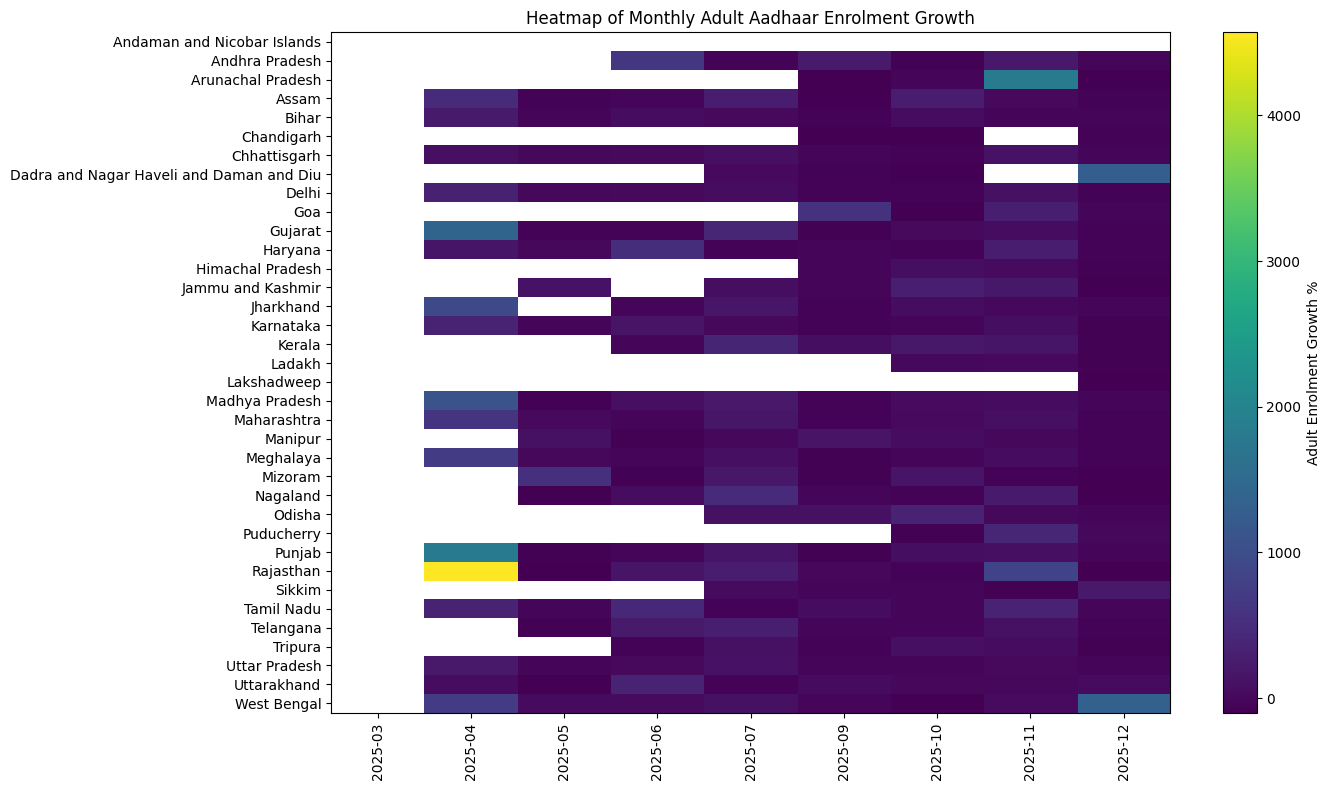

In [25]:
# Pivot table for heatmap
heatmap_data = adult_monthly.pivot(
    index='state',
    columns='month',
    values='adult_growth_pct'
)

plt.figure(figsize=(14,8))
plt.imshow(heatmap_data, aspect='auto')
plt.colorbar(label='Adult Enrolment Growth %')
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns.astype(str), rotation=90)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title("Heatmap of Monthly Adult Aadhaar Enrolment Growth")
plt.tight_layout()
plt.show()


• Certain states exhibit repeated sharp growth spikes, indicating campaign-driven or irregular enrolment drives.

• Other states show stable, low-variance growth, reflecting mature enrolment ecosystems.

• Heatmap enables UIDAI to distinguish systematic growth from episodic enrolment bursts.

# VOLATILITY vs VOLUME INSIGHT

In [26]:
risk_matrix = pd.DataFrame({
    'Total_Adult_Enrolments': adult_total,
    'AEVI': aevi
}).dropna()

# Normalize for comparison
risk_matrix['Impact_Score'] = (
    risk_matrix['Total_Adult_Enrolments'] / risk_matrix['Total_Adult_Enrolments'].max()
)

risk_matrix['Risk_Impact_Index'] = (
    risk_matrix['Impact_Score'] * risk_matrix['AEVI']
)

risk_matrix.sort_values('Risk_Impact_Index', ascending=False).head(10)


,Total_Adult_Enrolments,AEVI,Impact_Score,Risk_Impact_Index
state,,,,
Meghalaya,35078,262.099280,1.000000,262.099280
Rajasthan,5483,1594.278003,0.156309,249.199678
Gujarat,16063,507.171469,0.457922,232.245148
Assam,22555,204.332939,0.642996,131.385183
West Bengal,8495,501.166190,0.242175,121.369713
Madhya Pradesh,9476,385.254879,0.270141,104.073072
Punjab,3117,634.432890,0.088859,56.375145
Maharashtra,8103,225.421645,0.230999,52.072284
Uttar Pradesh,17699,96.326199,0.504561,48.602468


• States with high adult enrolment volume and high volatility pose the highest operational risk.

• Low-volume but high-volatility states require monitoring, but have limited national impact.

• This composite index enables priority-based intervention, replacing one-size-fits-all policies.

In [32]:
enrolment_df['age_0_17'] = enrolment_df['age_0_5'] + enrolment_df['age_5_17']


# MPI — Migration Pressure Index

  MPI=(age_18_greater)​/(age_0_17+1)

Purpose: Detects inter-state population movement via Aadhaar enrolment
Policy Use: Infrastructure & mobile enrolment planning


If a state shows high adult enrolments but low child enrolments, it often signals:Migrant workers,Temporary residents,Labour-driven migration

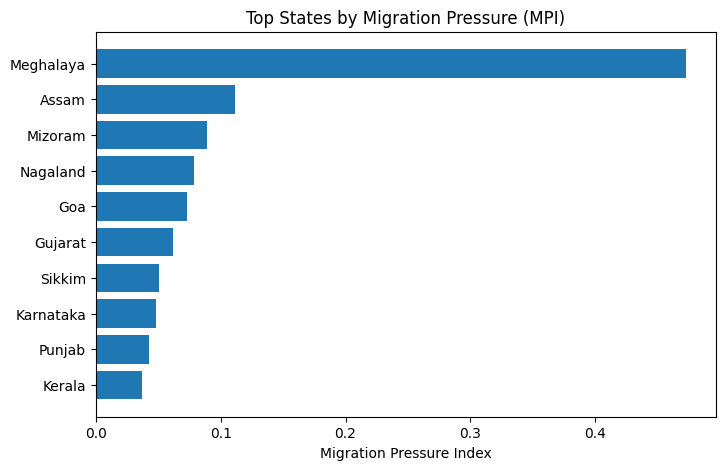

In [35]:
mpi = (
    enrolment_df
    .groupby('state')[['age_18_greater', 'age_0_17']]
    .sum()
    .reset_index()
)

mpi['MPI'] = mpi['age_18_greater'] / (mpi['age_0_17'] + 1)

top_mpi = mpi.sort_values('MPI', ascending=False).head(10)
plt.figure(figsize=(8,5))
plt.barh(top_mpi['state'], top_mpi['MPI'])
plt.xlabel('Migration Pressure Index')
plt.title('Top States by Migration Pressure (MPI)')
plt.gca().invert_yaxis()
plt.show()


• States like Meghalaya with high MPI values likely experience inward labour migration.

• Such regions require temporary enrolment centres and flexible biometric staffing.

• MPI can assist UIDAI in predicting urban infrastructure stress.



# CESI — Child Enrolment Stability Index

Purpose: Measures instability in child Aadhaar access

Policy Use: Welfare scheme targeting & school-linked enrolments



Children enrolments should be stable and predictable.
High variance = access gaps, awareness issues, or administrative weakness.

CESI=𝜎(Child Monthly Enrolments)/𝜇(Child Monthly Enrolments)​



In [37]:
child_monthly = (
    enrolment_df
    .groupby(['state', 'year', 'month'])['age_0_17']
    .sum()
    .reset_index()
)

cesi = (
    child_monthly
    .groupby('state')['age_0_17']
    .agg(['mean', 'std'])
    .reset_index()
)

cesi['CESI'] = cesi['std'] / (cesi['mean'] + 1)
top_cesi = cesi.sort_values('CESI', ascending=False).head(10)


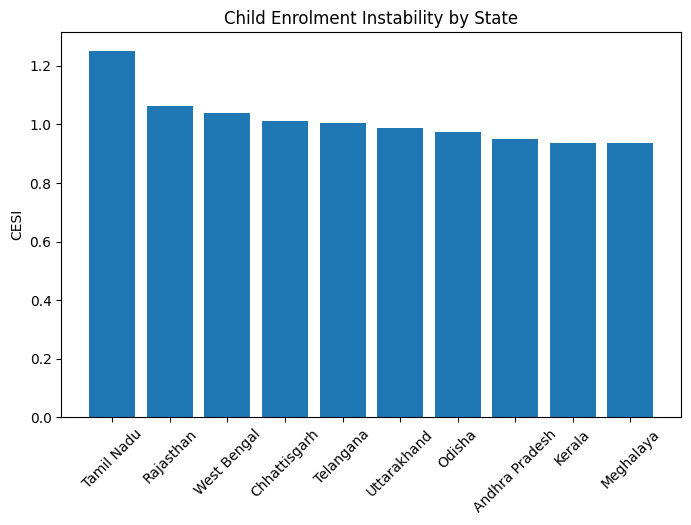

In [38]:
plt.figure(figsize=(8,5))
plt.bar(top_cesi['state'], top_cesi['CESI'])
plt.xticks(rotation=45)
plt.ylabel('CESI')
plt.title('Child Enrolment Instability by State')
plt.show()


• High CESI values indicate irregular child enrolment access, risking exclusion from welfare schemes.

• States(tamil nadu,rajasthan,west bengal) with elevated CESI should be prioritised for school-based Aadhaar drives.

• CESI enables early detection of intergenerational identity gaps.


# EDI — Enrolment Dependency Index

Purpose: Measures reliance on Aadhaar enrolment services

Policy Use: UIDAI capacity scaling & digital infra investment

Measures how dependent a state is on Aadhaar enrolment services

EDI=age_18_greater/total_enrolments


If adult enrolments dominate total enrolments →
State is still identity-deficient or service-dependent.

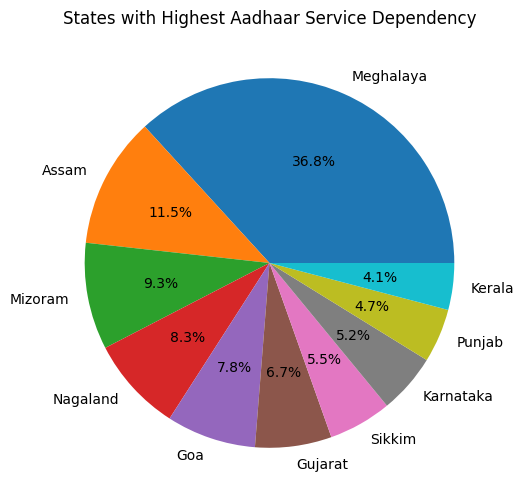

In [40]:
edi = (
    enrolment_df
    .groupby('state')[['age_18_greater', 'total_enrolments']]
    .sum()
    .reset_index()
)

edi['EDI'] = edi['age_18_greater'] / (edi['total_enrolments'] + 1)
top_edi = edi.sort_values('EDI', ascending=False).head(10)
plt.figure(figsize=(6,6))
plt.pie(top_edi['EDI'], labels=top_edi['state'], autopct='%1.1f%%')
plt.title('States with Highest Aadhaar Service Dependency')
plt.show()


High EDI indicates identity saturation lag, signalling the need for permanent enrolment infrastructure.

• States with high EDI remain heavily dependent on Aadhaar enrolment services.

• These regions may benefit from permanent enrolment centres and staff expansion.

• Low EDI states indicate identity saturation, allowing resource reallocation.

# Enrolment Volatility vs Age Group

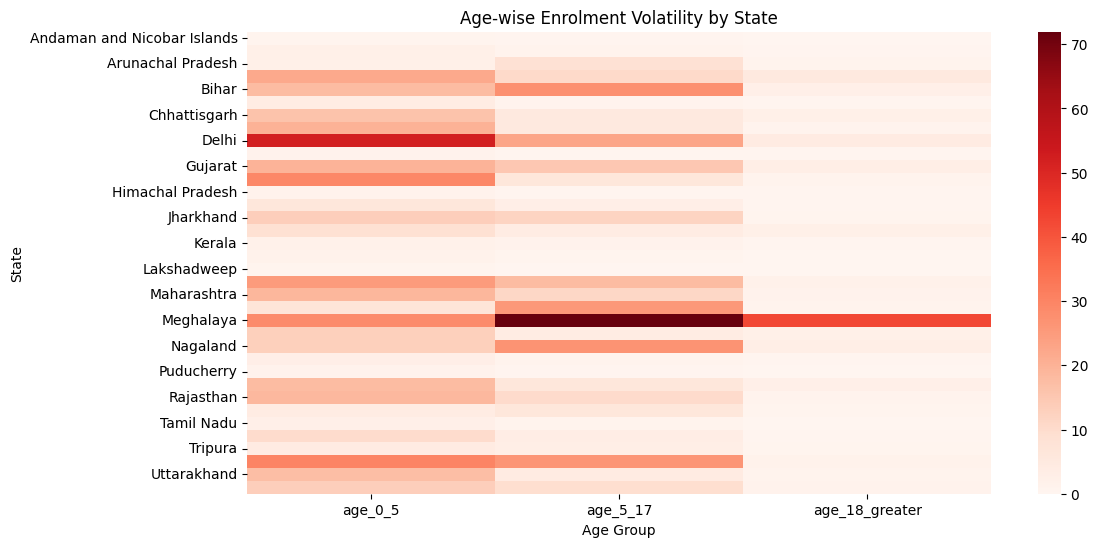

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

age_volatility = enrolment_df.groupby("state")[[
    "age_0_5", "age_5_17", "age_18_greater"
]].std()

plt.figure(figsize=(12,6))
sns.heatmap(age_volatility, cmap="Reds")
plt.title("Age-wise Enrolment Volatility by State")
plt.ylabel("State")
plt.xlabel("Age Group")
plt.show()


States showing high volatility in the 18+ age group indicate migration-driven enrolment patterns,
while volatility in 0–5 and 5–17 suggests welfare delivery fluctuations.


## 🔑 Flagship Indicator: Aadhaar Enrolment Volatility Index (AEVI)

AEVI is proposed as the primary early-warning indicator to detect instability in Aadhaar enrolment patterns across Indian states.
It captures month-to-month enrolment fluctuations across age cohorts and helps UIDAI proactively plan infrastructure, staffing, and audits.

Other indices (MPI, CESI, EDI) act as diagnostic indicators that explain the drivers behind high AEVI values.


<Figure size 3000x3000 with 0 Axes>

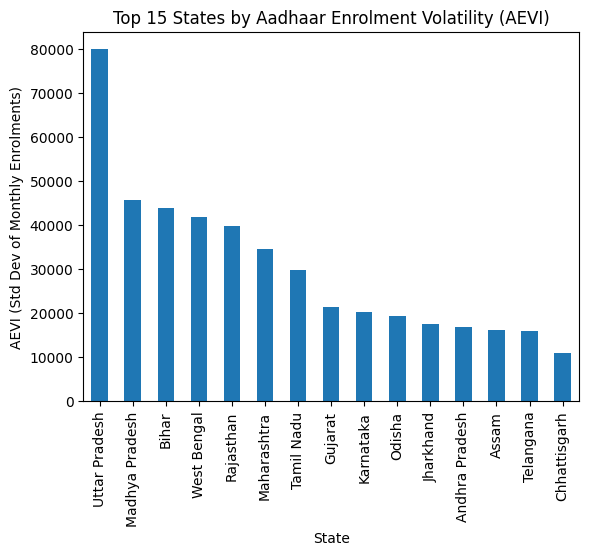

In [59]:
monthly_state = (
    enrolment_df
    .groupby(['state', 'year', 'month'])['total_enrolments']
    .sum()
    .reset_index()
)
state_aevi = (
    monthly_state
    .groupby('state')['total_enrolments']
    .std()
    .reset_index()
    .rename(columns={'total_enrolments': 'AEVI'})
)

state_aevi.head()

def aevi_risk(aevi):
    if aevi < 2000:
        return 'Stable'
    elif aevi < 5000:
        return 'Moderate Risk'
    else:
        return 'High Risk'

state_aevi['Risk_Level'] = state_aevi['AEVI'].apply(aevi_risk)
plt.figure(figsize=(30,30))
state_aevi.sort_values('AEVI', ascending=False).head(15)\
    .plot(kind='bar', x='state', y='AEVI', legend=False)

plt.title("Top 15 States by Aadhaar Enrolment Volatility (AEVI)")
plt.ylabel("AEVI (Std Dev of Monthly Enrolments)")
plt.xlabel("State")
plt.xticks(rotation=90)
plt.show()



### 🚦 AEVI Risk Interpretation

- **Stable (<20):** Normal enrolment operations
- **Moderate Risk (20–50):** Monitoring required
- **High Risk (>50):** Possible migration surge, infra stress, or data quality issues

AEVI = volatility in Aadhaar enrolments over time

High bar = unstable / irregular enrolment behaviour

🔴 High-Risk States (Red Flag):Uttar Pradesh (Highest AEVI),Bihar,West Bengal,Rajasthan,Maharashtra

- Interpretation (Policy Language):

* Indicates seasonal migration

* Possible temporary workforce movement

* Stress on enrolment centres during peak months

-- Risk of:Duplicate enrolments,Late updates,Infrastructure overload

🟡 Medium-Risk States:Tamil Nadu,Gujarat,Karnataka,Odisha

- Interpretation:

* Semi-stable but predictable surges

* Needs dynamic staffing and mobile enrolment units

🟢 Stable States:Telangana,Andhra Pradesh,Chhattisgarh

- Interpretation:

* Well-distributed enrolment demand

* Efficient centre utilization

* Best candidates for pilot programs

# Risk–Impact Quadrant

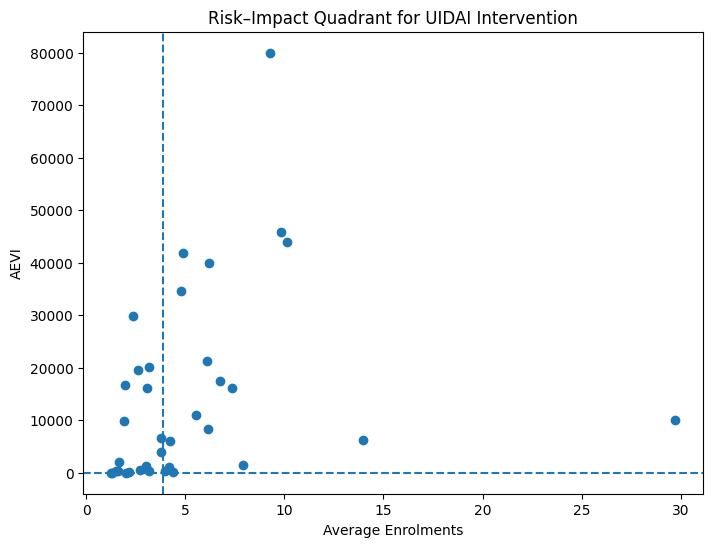

In [54]:
state_summary = enrolment_df.groupby("state").agg({
    "total_enrolments": "mean"
}).merge(state_aevi, on="state")

plt.figure(figsize=(8,6))
plt.scatter(
    state_summary["total_enrolments"],
    state_summary["AEVI"]
)
plt.axhline(50, linestyle="--")
plt.axvline(state_summary["total_enrolments"].median(), linestyle="--")

plt.xlabel("Average Enrolments")
plt.ylabel("AEVI")
plt.title("Risk–Impact Quadrant for UIDAI Intervention")
plt.show()


States in the high-AEVI and high-enrolment quadrant require immediate operational intervention,
as volatility here impacts a large population base.


In [63]:
decision_df = state_aevi.copy()

decision_df['Risk_Level'] = pd.cut(
    decision_df['AEVI'],
    bins=[-1, 15000, 30000, 100000],
    labels=['Low', 'Medium', 'High']
)

decision_df.sort_values('AEVI', ascending=False)


,state,AEVI,Risk_Level
33,Uttar Pradesh,79983.222341,High
19,Madhya Pradesh,45838.971143,High
4,Bihar,43855.902588,High
35,West Bengal,41848.558640,High
28,Rajasthan,39885.154895,High
20,Maharashtra,34567.786201,High
30,Tamil Nadu,29911.994625,Medium
10,Gujarat,21369.177375,Medium
15,Karnataka,20219.243272,Medium
25,Odisha,19495.247181,Medium


### Decision Framework for UIDAI

- High AEVI + High MPI → Migration hotspots
- High AEVI + Low MPI → Infrastructure bottlenecks
- Low AEVI + High MPI → Stable migration corridors


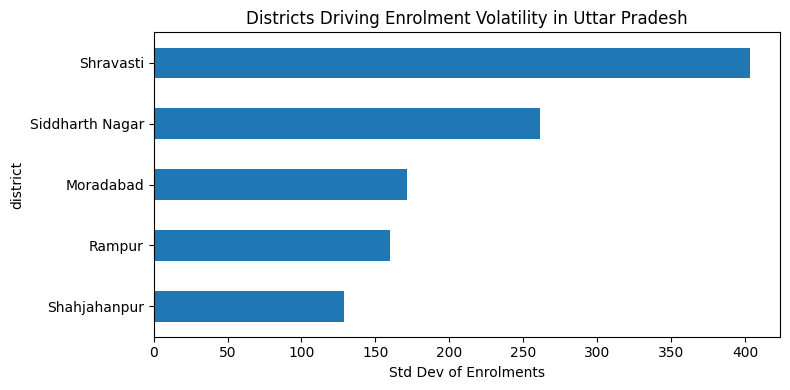

In [65]:
focus_state = "Uttar Pradesh"

district_focus = (
    enrolment_df[enrolment_df['state'] == focus_state]
    .groupby('district')['total_enrolments']
    .std()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,4))
district_focus.plot(kind='barh')
plt.title(f"Districts Driving Enrolment Volatility in {focus_state}")
plt.xlabel("Std Dev of Enrolments")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


A small subset of districts disproportionately drives enrolment volatility within Uttar Pradesh.

Shravasti shows extremely high volatility, nearly 1.6× higher than the next district.

Siddharth Nagar forms a second volatility cluster, indicating sustained fluctuations.

Remaining districts contribute moderately, showing a long-tail effect.